### Импорт библиотек

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

###Загрузка данных

In [59]:
data = pd.read_csv('IMOEX_data.csv', thousands='.', decimal=',', dtype={'Дата': str})

###Изменяем индексы

In [36]:
data = data.iloc[::-1].reset_index(drop=True)

###Первые 5 строк

In [60]:

data.head()

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %
0,01.03.2026,2776.37,2823.19,2912.01,2766.28,"59,81B","-0,81%"
1,01.02.2026,2799.14,2758.01,2809.49,2712.47,"41,38B","0,59%"
2,01.01.2026,2782.74,2733.01,2843.63,2674.17,"953,35B","0,58%"
3,01.12.2025,2766.62,2674.51,2819.33,2619.88,"185,55B","3,37%"
4,01.11.2025,2676.42,2524.01,2713.02,2492.20,NaN,"5,99%"


### Типы данных

In [22]:
print(data.dtypes)

Дата,"Цена","Откр.","Макс.","Мин.","Объём","Изм. %"    object
dtype: object


###Пропуски

In [21]:
print(data.isnull().sum())

Дата,"Цена","Откр.","Макс.","Мин.","Объём","Изм. %"    0
dtype: int64


###Расчет доходности в процентах

In [39]:
data["returns"] = data["Цена"].pct_change() * 100
data["returns"]


,returns
0,NaN
1,-2.766954
2,-0.417059
3,2.830643
4,1.386903
...,...
115,5.988437
116,3.370174
117,0.582660
118,0.589347


###Средняя доходность

In [50]:
mean_profit = data["returns"].mean()
print(f"Средняя доходность: {mean_profit.round(2)}%")

Средняя доходность за месяц: 0.48%


###Стандартное отклонение

In [57]:
std_profit = data["returns"].std()
# :.2f означает "вывести 2 знака после запятой"
print(f"Волатильность: {std_profit:.2f}%")

Волатильность: 5.92%


### График цены

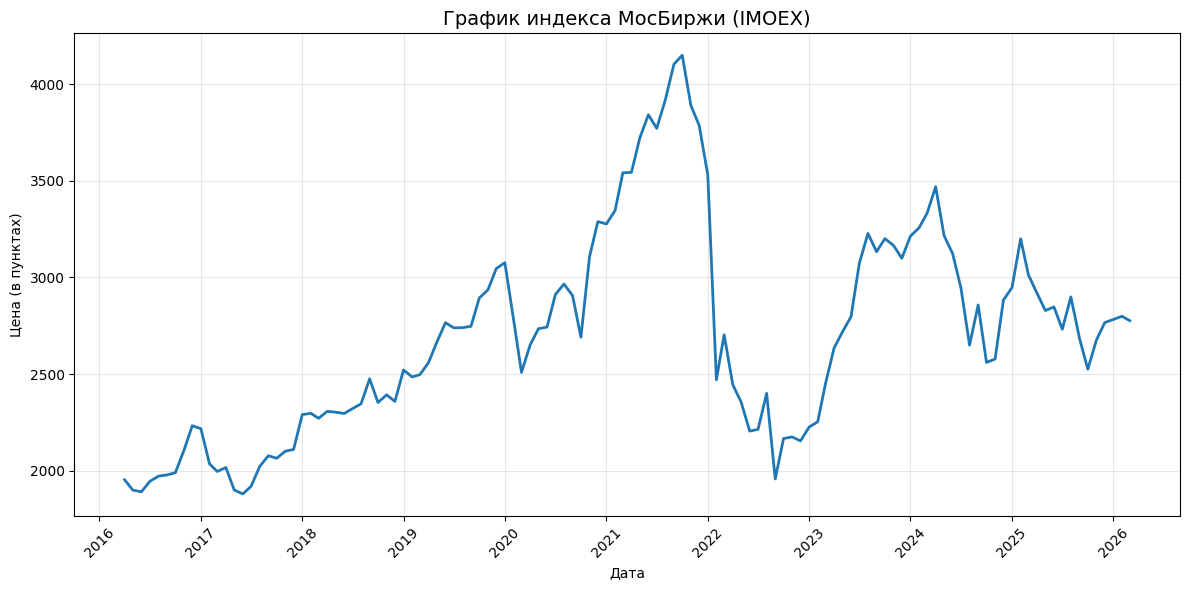

In [63]:
# Конвертация даты
data['Дата'] = pd.to_datetime(data['Дата'], format='%d.%m.%Y')

# Сам график
plt.figure(figsize=(12, 6))
plt.plot(data['Дата'], data['Цена'], color='#1f77b4', linewidth=2)

# Оформление
plt.title('График индекса МосБиржи (IMOEX)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Цена (в пунктах)')
plt.grid(True, alpha=0.3)

# Чтобы даты на оси X не накладывались друг на друга
plt.xticks(rotation=45)

# Чтобы все подписи влезли
plt.tight_layout()


plt.show()